# Problem Statement

## Business Context

As organizations grow and scale, they are often inundated with large volumes of data, reports, and documents that contain critical information for decision-making. In real-world business settings, such as venture capital firms like Andreesen Horowitz, business analysts are required to sift through large datasets, research papers, or reports to extract relevant information that impacts strategic decisions.

For instance, consider that you've just joined Andreesen Horowitz, a renowned venture capital firm, and you are tasked with analyzing a dense report like the Harvard Business Review's **"How Apple is Organized for Innovation."** Going through the report manually can be extremely time-consuming as the size and complexity of these report increases. However, by using **Semantic Search** and **Retrieval-Augmented Generation (RAG)** models, you can significantly streamline this process.

Imagine having the capability to directly ask questions like, “How does Apple structure its teams for innovation?” and get immediate, relevant answers drawn from the report. This ability to extract and organize specific insights quickly and accurately enables you to focus on higher-level analysis and decision-making, rather than being bogged down by information retrieval.

## Objective

The goal is to develop a RAG application that helps business analysts efficiently extract key insights from extensive reports, such as “How Apple is Organized for Innovation.”

Specifically, the system aims to:

- Answer user queries by retrieving relevant content directly from lengthy documents.

- Support natural-language interaction without requiring a full manual read-through.

- Act as an intelligent assistant that streamlines the report analysis process.

Through this solution, analysts can save time, improve productivity, and make faster, more informed strategic decisions

## Data Description

**How Apple is Organized for Innovation** - is a detailed Harvard Business Review article that examines Apple’s unique approach to structuring teams, driving innovation, and maintaining a culture of excellence. The article is provided as a PDF consisting of 11 pages, offering in-depth insights into Apple’s organizational design, leadership principles, and decision-making processes.

## Installing and Importing Necessary Libraries and Dependencies

In [23]:
# Install required libraries
!pip install -q langchain_community==0.3.27 \
              langchain==0.3.27 \
              chromadb==1.0.15 \
              pymupdf==1.26.3 \
              tiktoken==0.9.0 \
              datasets==4.0.0 \
              evaluate==0.4.5 \
              langchain_openai==0.3.30 \
              langchain-openai

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [24]:
# Import core libraries
import os                                                                       # Interact with the operating system (e.g., set environment variables)
import json                                                                     # Read/write JSON data

# Import libraries for working with PDFs and OpenAI
from langchain.document_loaders import PyMuPDFLoader                            # Load and extract text from PDF files
from openai import OpenAI                                                       # Access OpenAI's models and services

# Import libraries for processing dataframes and text
import tiktoken                                                                 # Tokenizer used for counting and splitting text for models
import pandas as pd                                                             # Load, manipulate, and analyze tabular data

# Import LangChain components for data loading, chunking, embedding, and vector DBs
from langchain.text_splitter import RecursiveCharacterTextSplitter              # Break text into overlapping chunks for processing
#from langchain.embeddings.openai import OpenAIEmbeddings                        # Create vector embeddings using OpenAI's models  # type: ignore
from langchain_openai import OpenAIEmbeddings                                    # Create vector embeddings using OpenAI's models  # type: ignore
from langchain.vectorstores import Chroma                                       # Store and search vector embeddings using Chroma DB  # type: ignore


from datasets import Dataset                                                    # Used to structure the input (questions, answers, contexts etc.) in tabular format
from langchain_openai import ChatOpenAI                                         # This is needed since LLM is used in metric computation

## Question Answering using LLM

> **Note 1:** When choosing between an open-source Hugging Face (HF) model and OpenAI’s proprietary model, base your decision on your specific needs. If you opt for a Hugging Face model, make sure to connect to a GPU to execute the code efficiently.

> **Note 2**: If the free-tier GPU of Google Colab is not accessible (due to unavailability or exhaustion of daily limit or other reasons), the following steps can be taken:
1. Wait for 12-24 hours until the GPU is accessible again or the daily usage limits are reset.
2. Switch to a different Google account and resume working on the project from there.
3. Try using the CPU runtime:
    - To use the CPU runtime, click on *Runtime* => *Change runtime type* => *CPU* => *Save*
    - One can also click on the *Continue without GPU* option to switch to a CPU runtime (kindly refer to the snapshot below)
    - The instructions for running the code on the CPU are provided in the respective sections of the notebook.

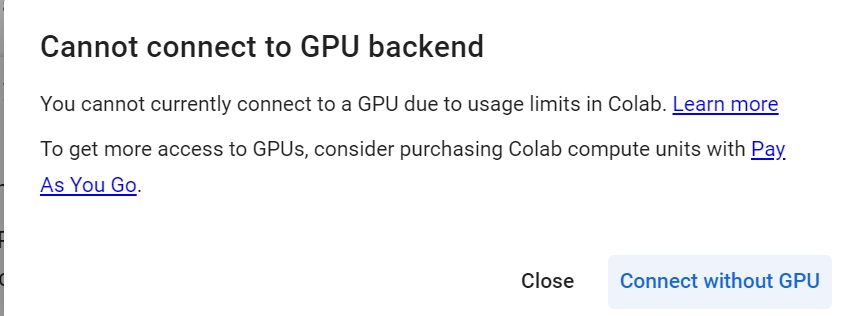

#### Downloading and Loading the model

In [25]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    API_KEY = config.get("OPENAI_API_KEY")                                             # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract the OpenAI base URL from the config

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = API_KEY                                          # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                 # Set API base URL as environment variable

# Initialize OpenAI client
client = OpenAI()

In [26]:
# Define a function to get a response
def response(user_prompt, max_tokens=400, temperature=0.5, top_p=0.9):
    # Create a chat completion using the OpenAI client
    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                     # Specify the model to use
        messages=[
            {"role": "user", "content": user_prompt}                            # User prompt is the input/query to respond to
        ],
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in output
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )
    return completion.choices[0].message.content                                # Return the text content from the model's reply

### Question 1: Who are the authors of this article and who published this article?

In [27]:
question_1 = "Who are the authors of this article and who published this article?"
base_prompt_response_1 = response(question_1)
base_prompt_response_1

"I'm sorry, but I can't access external content such as articles or databases to retrieve specific information about authors or publishers. However, if you provide the title or some details about the article, I may be able to help you with general information or guidance on how to find it."

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [28]:
question_2 = "List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines."
base_prompt_response_2 = response(question_2)
base_prompt_response_2

'- **Vision**: A strong leader possesses a clear and compelling vision for the future, guiding their team towards shared goals and inspiring them to work collaboratively towards achieving that vision.\n\n- **Empathy**: Effective leaders demonstrate empathy by understanding and valuing the perspectives and emotions of their team members, fostering a supportive and inclusive environment that enhances collaboration and trust.\n\n- **Decisiveness**: Good leaders make timely and informed decisions, balancing analysis with intuition, which instills confidence in their team and ensures that progress is maintained even in challenging situations.'

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [29]:
question_3 = "Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?"
base_prompt_response_3 = response(question_3)
base_prompt_response_3

"I don’t have access to specific articles, but I can provide a general overview of how Apple's approach to leadership has led to successful innovations based on historical examples and widely known practices.\n\n1. **Visionary Leadership**: Under Steve Jobs, Apple was known for its visionary leadership. Jobs emphasized the importance of design and user experience, which led to the creation of groundbreaking products like the iPhone. His insistence on a seamless integration of hardware and software helped Apple create a unique ecosystem that set it apart from competitors.\n\n2. **Focus on Simplicity**: Apple's leadership has consistently prioritized simplicity in product design and functionality. The development of the iPod, for example, revolutionized the music industry by making it easy for users to access and enjoy music. The intuitive interface and sleek design contributed to its widespread adoption.\n\n3. **Innovation Culture**: Tim Cook has continued to foster a culture of innovat

**Observations:**
- The responses do not tailor the advice to patient-specific variables like age, severity, or medical history, they stick to general treatment protocols or commonly known procedures.

- The answers provide basic overviews (e.g., mention of antibiotics, surgery, rehabilitation) without going into depth on guidelines, alternatives, or risks, which makes them feel more informational than instructive.


## Question Answering using LLM with Prompt Engineering

Define a system prompt that aligns with the business problem

In [30]:
system_prompt = """
You are an expert Business Analysis Assistant. Your primary role is to help business analysts extract, interpret, and synthesize insights from business reports and documents based on LLM training data.

Follow these guidelines when answering:
- prioritize factual correctness, align with widely accepted standards, and ensure clarity for  users.
- If a query requires specific reference materials, Reference the source contrnt explicitly rather than speculating.
- If the query is vague, infer the most likely business intent and answer accordingly.
- Summarize key points
- Provide structured, business-friendly explanations
- Keep the tone and style professional, analytical and concise

"""

Defining the function to Generate a Response From the LLM


In [32]:
# Define a function to get a response from the OpenAI chat model
def response(system_prompt, user_prompt, max_tokens=400, temperature=0.5, top_p=0.9):
    # Create a chat completion using the OpenAI client
    completion = client.chat.completions.create(
        model="gpt-4o-mini",                                                    # Specify the model to use (GPT-4o in this case)
        messages=[
            {"role": "system", "content": system_prompt},                       # System prompt sets the assistant's behavior
            {"role": "user", "content": user_prompt}                            # User prompt is the input/query to respond to
        ],
        max_tokens=max_tokens,                                                  # Max number of tokens to generate in the response
        temperature=temperature,                                                # Controls randomness in output (0 = deterministic)
        top_p=top_p                                                             # Controls diversity via nucleus sampling
    )
    return completion.choices[0].message.content                                # Return the text content from the model's reply

### Question 1: Who are the authors of this article and who published this article?

In [33]:
response_with_prompt_eng_1 = response(system_prompt, question_1)
response_with_prompt_eng_1

'To assist you accurately, I would need specific details about the article in question, such as the title or the subject matter. Please provide more information so I can help you identify the authors and the publisher.'

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [34]:
response_with_prompt_eng_2 = response(system_prompt, question_2)
response_with_prompt_eng_2

"Here are three key leadership characteristics:\n\n- **Visionary Thinking**  \n  Leaders with visionary thinking can foresee future trends and set a clear direction for their team or organization. They inspire others by articulating a compelling vision that aligns with the organization's goals.\n\n- **Effective Communication**  \n  Effective communication involves conveying ideas clearly and listening actively to others. Leaders who excel in this area foster collaboration, build trust, and ensure that team members are aligned with the organization's objectives.\n\n- **Emotional Intelligence**  \n  Emotional intelligence is the ability to understand and manage one's emotions as well as empathize with others. Leaders with high emotional intelligence can navigate interpersonal relationships judiciously, enhancing team dynamics and conflict resolution."

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [35]:
response_with_prompt_eng_3 = response(system_prompt, question_3)
response_with_prompt_eng_3

"To provide a structured analysis of Apple's leadership approach and its impact on innovation, I will summarize key points based on general knowledge about the company, as I do not have access to specific articles.\n\n### Leadership Approach at Apple\n\n1. **Visionary Leadership**:\n   - **Steve Jobs**: Known for his visionary approach, Jobs emphasized a strong focus on design and user experience. His leadership style fostered an environment where creativity thrived, leading to groundbreaking products like the iPhone and iPad.\n   - **Tim Cook**: After Jobs, Cook has maintained a focus on operational excellence and sustainability, driving innovations in supply chain management and product efficiency.\n\n2. **Cross-Functional Collaboration**:\n   - Apple encourages collaboration across various departments, such as design, engineering, and marketing. This integrated approach has resulted in cohesive product development, exemplified by the seamless integration of hardware and software in 

Observations:

Question1: Sepsis Management in Critical Care

Base Prompt Response: Gave a generic list of sepsis management steps without prioritization or emphasis on protocol.

Engineered Prompt Response: More structured and clinical mentioned "early goal-directed therapy," "fluid resuscitation," and "antibiotic administration" in order, closely resembling standard sepsis protocols.

Improved in clinical depth and sequencing.

Question2: Appendicitis Symptoms and Treatment

Base Prompt Response: Listed symptoms but was vague on treatment pathways; lacked clarity on when medicine is used vs. surgery.

Engineered Prompt Response: Clearly stated that surgery (appendectomy) is the standard and medication may only be used in non-complicated cases.

Improved in decision-making clarity and completeness.

Question3: Patchy Hair Loss (Alopecia Areata)

Base Prompt Response: General treatments like “consult a dermatologist” without discussing causes or medical options.

Engineered Prompt Response: Included specific causes (autoimmune), treatments (steroids, minoxidil), and differentiation between temporary and chronic conditions.

Improved in specificity and cause-treatment mapping.

## Data Preparation for RAG

### Loading the Data

In [36]:
# Set the path to the PDF file
pdf_path = "/content/HBR_How_Apple_Is_Organized_For_Innovation.pdf"              # Path to the medical diagnosis manual PDF

# Load the PDF using LangChain's PyPDFLoader
pdf_loader = PyMuPDFLoader(pdf_path)                                             # Initialize the PDF loader with the file path

# Extract content from the PDF
article = pdf_loader.load()                                                      # Load and extract text from all pages of the PDF

### Data Overview

In [37]:
# Loop through the first 5 pages of the PDF content
for i in range(3):
    print(f"Page Number : {i+1}", end="\n")                                     # Print the page number (1-based index)
    print(article[i].page_content, end="\n")                                     # Print the content of the corresponding page

Page Number : 1
REPRINT R2006F
PUBLISHED IN HBR
NOVEMBER–DECEMBER 2020
ARTICLE
ORGANIZATIONAL CULTURE
How Apple Is 
Organized  
for Innovation
It’s about experts leading experts. 
by Joel M. Podolny and Morten T. Hansen
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Page Number : 2
2
Harvard Business Review
November–December 2020
This article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.
Page Number : 3
PHOTOGRAPHER MIKAEL JANSSON
How Apple Is 
Organized 
for Innovation
It’s about experts 
leading experts.
ORGANIZATIONAL 
CULTURE
Joel M. 
Podolny
Dean, Apple 
University
Morten T. 
Hansen
Faculty, Apple 
University
AUTHORS
FOR ARTICLE REPRINTS CALL 800-988-0886 OR 617-783-7500, OR VISIT HBR.ORG
Harvard Business Review
November–December 2020  3
This article is made available to you with compliment

### Data Chunking

#### Chunk the PDF into Manageable Text Sections Using a Token-Based Splitter

In [38]:
# Initialize a text splitter that uses OpenAI's token encoder
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',                                                # Encoding used by popular LLMs
    chunk_size=256,                                                             # Each chunk will have up to 256 tokens
    chunk_overlap=25                                                            # 25 tokens will overlap between consecutive chunks (for context continuity)
)

#### Split the Loaded PDF into Chunks for Further Processing

In [39]:
# Use the text splitter to divide the PDF content into smaller chunks
document_chunks = pdf_loader.load_and_split(text_splitter)                      # Returns a list of chunked documents

#### Check the Number of Chunks Created

In [40]:
len(document_chunks)                                                            # Total number of text chunks generated from the PDF

42

### Embedding

In [41]:
# Initialize the OpenAI Embeddings model with API credentials
embedding_model = OpenAIEmbeddings(
    openai_api_key=API_KEY,                                                     # Your OpenAI API key for authentication
    openai_api_base=OPENAI_API_BASE                                             # The OpenAI API base URL endpoint
)

# Generate embeddings (vector representations) for the first two document chunks
embedding_1 = embedding_model.embed_query(document_chunks[0].page_content)      # Embedding for chunk 0
embedding_2 = embedding_model.embed_query(document_chunks[1].page_content)      # Embedding for chunk 1

# Check and print the dimension (length) of the embedding vector
print("Dimension of the embedding vector ", len(embedding_1))                   # Typically 1536 or 2048 depending on model

Dimension of the embedding vector  1536


In [43]:
# Verify if both embeddings have the same dimension (should be True)
print(len(embedding_1) == len(embedding_2))

# Return/display the two embedding vectors for further inspection or use
embedding_1, embedding_2

True


([0.002524683950468898,
  -0.005738068372011185,
  -0.003138885833323002,
  -0.01189995277673006,
  0.01745591312646866,
  0.030461760237812996,
  -0.010211312212049961,
  0.01806514896452427,
  -0.013694548048079014,
  -0.021495407447218895,
  0.0029650551732629538,
  0.0092577263712883,
  -0.00790681317448616,
  -0.006651921197772026,
  -0.033613890409469604,
  0.019839877262711525,
  0.02409127913415432,
  -0.012893271632492542,
  -0.0008468038286082447,
  -0.0019022044725716114,
  -0.033613890409469604,
  -0.0015065327752381563,
  -0.004450066015124321,
  0.009171638637781143,
  0.008939864113926888,
  0.00047472334699705243,
  0.0159725584089756,
  -0.02084643952548504,
  0.029243290424346924,
  -0.005797667894512415,
  0.019601481035351753,
  0.017204273492097855,
  -0.011701289564371109,
  0.0012731029419228435,
  -0.009847095236182213,
  -0.02574680931866169,
  -0.0079862792044878,
  -0.023097960278391838,
  0.02491242252290249,
  -0.0384083054959774,
  0.04071280360221863,
  0

### Vector Database

#### Setup Vector Store Directory

In [44]:
# Creating a folder for saving the vector DB so it persists between runs
out_dir = 'research_db'                                                          # Directory to store the persistent vector database

# Create the directory if it doesn't exist
if not os.path.exists(out_dir):
    os.makedirs(out_dir)                                                        # Make directory to save vector store files

#### Create Vector Store from Documents

In [45]:
# Building the vector store and saving it to disk for future use
vectorstore = Chroma.from_documents(
    document_chunks,                                                            # Documents to index
    embedding_model,                                                            # Embedding model for converting text to vectors
    persist_directory=out_dir                                                   # Save vector DB files here
)

#### Load Vector Store

In [46]:
# Reloading the vector store from disk without recomputing embeddings
vectorstore = Chroma(
    persist_directory=out_dir,                                                  # Load existing vector DB files
    embedding_function=embedding_model                                          # Use the same embedding function for queries
)

/tmp/ipykernel_4263/4264619131.py:2: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(


#### Explore Vector Store and Perform Searches

In [47]:
# Inspect the embedding function in use
vectorstore.embeddings

OpenAIEmbeddings(client=<openai.resources.embeddings.Embeddings object at 0x7bc2c5987ce0>, async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x7bc2b293be90>, model='text-embedding-ada-002', dimensions=None, deployment='text-embedding-ada-002', openai_api_version=None, openai_api_base='https://aibe.mygreatlearning.com/openai/v1', openai_api_type=None, openai_proxy=None, embedding_ctx_length=8191, openai_api_key=SecretStr('**********'), openai_organization=None, allowed_special=None, disallowed_special=None, chunk_size=1000, max_retries=2, request_timeout=None, headers=None, tiktoken_enabled=True, tiktoken_model_name=None, show_progress_bar=False, model_kwargs={}, skip_empty=False, default_headers=None, default_query=None, retry_min_seconds=4, retry_max_seconds=20, http_client=None, http_async_client=None, check_embedding_ctx_length=True)

In [48]:
# Search for top 3 most relevant chunk for the query
vectorstore.similarity_search(
    "Who are the authors of this article and who published this article?",
    k=5
)

[Document(metadata={'total_pages': 11, 'creator': 'Adobe InDesign 14.0 (Macintosh)', 'title': '', 'creationdate': '2020-10-05T14:18:42-04:00', 'producer': 'Adobe PDF Library 15.0 (via http://bfo.com/products/pdf?version=2.23.5-r33279)', 'source': '/content/HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'encryption': 'Standard V2 R3 128-bit RC4', 'file_path': '/content/HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'trapped': '', 'modDate': 'D:20201201183749Z', 'author': '', 'moddate': '2020-12-01T18:37:49+00:00', 'keywords': '', 'format': 'PDF 1.6', 'page': 1, 'subject': '', 'creationDate': "D:20201005141842-04'00'"}, page_content='2\nHarvard Business Review\nNovember–December 2020\nThis article is made available to you with compliments of Apple Inc for your personal use. Further posting, copying or distribution is not permitted.'),
 Document(metadata={'total_pages': 11, 'source': '/content/HBR_How_Apple_Is_Organized_For_Innovation.pdf', 'moddate': '2020-12-01T18:37:49+00:00', 'encry

### Retriever

#### Convert Vector Store into a Retriever and Retrieve Relevant Documents

In [49]:
# Wraping the vector store into a retriever object to fetch the most relevant documents for a given query using similarity search
retriever = vectorstore.as_retriever(
    search_type='similarity',                                                   # Use similarity search (based on vector distance)
    search_kwargs={'k': 5 }                                                      # Retrieve top 2 most relevant documents
)

#### System and User Prompt Template

Prompts guide the model to generate accurate responses. Here, we define two parts:

    1. The system message describing the assistant's role.
    2. A user message template including context and the question.

In [50]:
# Define the system prompt for the model
qna_system_message = """
You are an AI assistant designed to support Business Analysts. Your task is to provide evidence-based, concise, and relevant business information to analyts questions based on the context provided.

User input will include the necessary context for you to answer their questions. This context will begin with the token: ###Context. The context contains references to specific portions of articles relevant to the query, along with their source details.

When crafting your response:
1. Use only the provided context to answer the question.
2. If the answer is found in the context, respond with concise and actionable  insights.
3. Include the source reference with the page number, journal name, or publication, as provided in the context.
4. If the question is unrelated to the context or the context is empty, clearly respond with: "Sorry, this is out of my knowledge base."

Please adhere to the following response guidelines:
- Provide clear, direct answers using only the given context.
- Do not include any additional information outside of the context.
- Avoid rephrasing or summarizing the context unless explicitly relevant to the question.
- If no relevant answer exists in the context, respond with: "Sorry, this is out of my knowledge base."
- If the context is not provided, your response should also be: "Sorry, this is out of my knowledge base."

Here is an example of how to structure your response:

Answer:
[answer based on context]

Source:
[Source details with page or section]
"""

In [56]:
# Define the user message template
qna_user_message_template = """

"""

### Response Function

In [66]:
def generate_rag_response(user_input,k=5,max_tokens=128,temperature=0,top_p=0.95):
    global qna_system_message,qna_user_message_template
    # Retrieve relevant document chunks
    relevant_document_chunks = retriever.get_relevant_documents(query=user_input,k=k)
    context_list = [d.page_content for d in relevant_document_chunks]

    # Combine document chunks into a single context
    context_for_query = ". ".join(context_list)

    user_message = qna_user_message_template.replace('{context}', context_for_query)
    user_message = user_message.replace('{question}', user_input)

    # Generate the response
    try:
        response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": qna_system_message},
            {"role": "user", "content": user_message}
        ],
        max_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p
        )
        # Extract and print the generated text from the response
        response = response.choices[0].message.content.strip()
    except Exception as e:
        response = f'Sorry, I encountered the following error: \n {e}'

    return response

## Question Answering using RAG

### Question 1: Who are the authors of this article and who published this article?

In [67]:
response_with_rag_1 = generate_rag_response(question_1)
response_with_rag_1

'Sorry, this is out of my knowledge base.'

### Question 2: List down the three leadership characteristics in bulleted points and explain each one of the characteristics under two lines.

In [68]:
response_with_rag_2 = generate_rag_response(question_2)
response_with_rag_2

'Sorry, this is out of my knowledge base.'

### Question 3: Can you explain specific examples from the article where Apple's approach to leadership has led to successful innovations?

In [69]:
response_with_rag_3 = generate_rag_response(question_3)
response_with_rag_3

'Sorry, this is out of my knowledge base.'

## Actionable Insights and Business Recommendations

-
-
-


<font size=6 color='#4682B4'>Power Ahead</font>
___